# Fine-tuning d’un modèle de triage médical — SFT puis DPO

Dans ce notebook, je construis une expérience reproductible autour de **Qwen3-1.7B-Base**. J’analyse mes données, j’entraîne d’abord le modèle en SFT, puis je poursuis avec un DPO et je compare les deux modèles sur **exactement le même jeu de test**.

J’utilise **Weights & Biases** pour suivre les paramètres, les pertes, les métriques, les prédictions et les artefacts. Ce travail reste un prototype pédagogique : il ne constitue pas un dispositif médical et ne doit pas être utilisé pour une décision clinique réelle.


## Table des matières

1. [Installation et imports](#1-installation-et-imports)
2. [Configuration reproductible](#2-configuration-reproductible)
3. [Chargement et normalisation](#3-chargement-et-normalisation)
4. [Audit des données](#4-audit-des-données)
5. [Préparation et split SFT](#5-préparation-et-split-sft)
6. [Entraînement SFT](#6-entraînement-sft)
7. [Évaluation complète SFT](#7-évaluation-complète-sft)
8. [Préparation DPO](#8-préparation-dpo)
9. [Entraînement DPO](#9-entraînement-dpo)
10. [Évaluation complète DPO](#10-évaluation-complète-dpo)
11. [Comparaison SFT/DPO](#11-comparaison-sftdpo)
12. [Conclusion et manifeste](#12-conclusion-et-manifeste)


## 1. Installation et imports

J’installe les bibliothèques une seule fois dans l’environnement. Après cette cellule, je redémarre le noyau si Jupyter le demande, puis je poursuis l’exécution.


In [1]:
import os

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"

print("✓ Hugging Face : mode local/offline")

# Standard
import gc
import hashlib
import json

import platform
import random
import re
import sys
from collections import Counter
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

# Data, affichage et utilitaires
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import wandb
from datasets import Dataset
from dotenv import load_dotenv
from IPython.display import display
from scipy.stats import binomtest
from tqdm.auto import tqdm

# PEFT
# Configure LoRA, prépare QLoRA et recharge les adapters entraînés.
from unsloth import FastModel

from peft import (
    LoraConfig,
    PeftModel,
    get_peft_model,
    prepare_model_for_kbit_training
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score
)
from sklearn.model_selection import StratifiedKFold, train_test_split

# Transformers
# Importe les composants nécessaires au SFT sans dépendre de TRL.

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
#    BitsAndBytesConfig,
    EarlyStoppingCallback,
    PreTrainedTokenizerBase,
    Trainer,
    TrainerCallback,
    TrainingArguments,
    set_seed                     # Reproductibilité Transformers/PyTorch
)

from transformers.utils.notebook import NotebookProgressCallback


✓ Hugging Face : mode local/offline
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W1007 11:17:51.180000 22296 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
# Vérification des versions critiques
# Bloque le notebook si l'environnement diffère de la pile validée.

from importlib.metadata import version
from packaging.specifiers import SpecifierSet
from packaging.version import Version

REQUIRED_VERSIONS = {
    "torch": ">=2.4,<2.12",
    "transformers": ">=4.56.2,<=5.5.0",
    "tokenizers": ">=0.22.0,<=0.23.0",
    "peft": ">=0.18,<0.20",
    "accelerate": ">=1.10,<2",
    "bitsandbytes": ">=0.48,<0.50",
    "datasets": ">=4.1.1,<4.4",
    "unsloth": ">=2026.9.1",
    "unsloth-zoo": ">=2025.7.4",
    "wandb": ">=0.22,<0.24"
}

installed_versions = {
    package: version(package)
    for package in REQUIRED_VERSIONS
}

invalid_versions = {
    package: {
        "installed": installed_versions[package],
        "required": required
    }
    for package, required in REQUIRED_VERSIONS.items()
    if Version(installed_versions[package]) not in SpecifierSet(required)
}

if invalid_versions:
    raise RuntimeError(
        f"Versions incompatibles : {invalid_versions}"
    )

version_report = pd.DataFrame([
    {
        "package": package,
        "installed": installed_versions[package],
        "required": required,
        "status": "OK"
    }
    for package, required in REQUIRED_VERSIONS.items()
])

display(version_report)

,package,installed,required,status
0,torch,2.11.0+cu130,">=2.4,<2.12",OK
1,transformers,5.5.0,">=4.56.2,<=5.5.0",OK
2,tokenizers,0.22.2,">=0.22.0,<=0.23.0",OK
3,peft,0.19.1,">=0.18,<0.20",OK
4,accelerate,1.15.0,">=1.10,<2",OK
5,bitsandbytes,0.49.2,">=0.48,<0.50",OK
6,datasets,4.3.0,">=4.1.1,<4.4",OK
7,unsloth,2026.9.12,>=2026.9.1,OK
8,unsloth-zoo,2026.9.8,>=2025.7.4,OK
9,wandb,0.23.1,">=0.22,<0.24",OK


## 2. Configuration reproductible

Je centralise les chemins et hyperparamètres dans une seule configuration. Les valeurs peuvent être adaptées, mais elles restent enregistrées dans W&B et dans le manifeste final.


In [3]:
# CHECKPOINT 750 epoch 4

# Configuration reproductible des entraînements SFT et DPO.

@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = 42                             # Graine de reproductibilité
    model_id: str = "Qwen/Qwen3-1.7B-Base"     # Modèle de base
    model_revision: str = "main"               # Révision Hugging Face

    sft_target: int = 5_000                    # Nombre d'exemples SFT
    dpo_target: int = 3_000                    # Nombre de paires DPO retenues

    test_size: float = 0.10                    # Part réservée au test
    validation_size: float = 0.10              # Part réservée à la validation

    sft_max_length: int = 2_048                # Longueur maximale SFT en tokens
    dpo_max_length: int = 2_048                # Longueur maximale DPO en tokens

    generation_max_new_tokens: int = 512       # Tokens générés pour prédire P1/P2/P3

    sft_train_batch_size: int = 1              # Batch SFT d'entraînement par GPU viser 16 ou 32 + 
    sft_eval_batch_size: int = 1               # Batch SFT d'évaluation par GPU
    sft_gradient_accumulation: int = 16        # Accumulation pour batch effectif ×8 au lieu de 8

    sft_warmup_ratio = 0.05
    sft_lr_scheduler_type = "cosine"           # demarrage progressif
    
# si trop haut on peut tricher avec per_device_train_batch = 1 ou 2  gradiant_accumualtion = 8

    dpo_train_batch_size: int = 1              # Batch DPO d'entraînement par GPU
    dpo_eval_batch_size: int = 1               # Batch DPO d'évaluation par GPU
    dpo_gradient_accumulation: int = 8         # Accumulation pour batch effectif ×8
    dpo_gradient_checkpointing: bool = False   # Désactivé pour limiter le surcoût DPO

    sft_epochs: float = 5.0                    # Nombre d'époques SFT

    sft_learning_rate: float = 2e-4            # Taux d'apprentissage LoRA SFT
    p1_loss_weight: float = 5 #1.5             # P1 renforcé
    priority_loss_weight: float = 5 #1.2       # P2/P3 inchangés
    im_end_loss_weight: float = 5 #1.2
    
    dpo_learning_rate: float = 5e-6            # Taux d'apprentissage DPO conservateur
    dpo_beta: float = 0.10                     # Force de régularisation DPO

    eval_steps: int = 50                       # Évaluation tous les 50 steps
    save_steps: int = 50                       # Checkpoint tous les 50 steps
    logging_steps: int = 10                    # Métriques tous les 10 steps

    wandb_enabled: bool = True                 # Active le suivi W&B
    wandb_project: str = "medical-triage-qwen3"  # Projet W&B

    strict_dataset_sizes: bool = True          # Impose les volumes attendus
    require_balanced_priorities: bool = True   # Impose l'équilibre P1/P2/P3
    priority_balance_tolerance: float = 0.02   # Tolérance d'écart entre priorités

    smoke_test: bool = False                    # Active un entraînement de contrôle
    smoke_steps: int = 10                      # Nombre de steps du smoke test

CONFIG = ExperimentConfig()

# Fige les générateurs aléatoires pour reproduire splits et entraînements.
set_seed(CONFIG.seed)
random.seed(CONFIG.seed)
np.random.seed(CONFIG.seed)

In [4]:
# Localise la racine du projet et définit les chemins du fine-tuning.

def find_project_root(start: Path | None = None) -> Path:
    """Localise la racine du projet."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (candidate / "data" / "raw" / "datasets").is_dir():
            return candidate

    raise FileNotFoundError("Répertoire data/raw/datasets introuvable.")


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "finetuning_sft_dpo"
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "datasets"
SPLIT_DIR = DATASET_DIR / "splits"

# Sources d'entraînement.

SFT_TRAIN_PATH = SPLIT_DIR / "sft_train.jsonl"
SFT_VALIDATION_PATH = SPLIT_DIR / "sft_validation.jsonl"
SFT_TEST_PATH = SPLIT_DIR / "sft_test.jsonl"

# Vérifie les sources.

for path in (
    SFT_TRAIN_PATH,
    SFT_VALIDATION_PATH,
    SFT_TEST_PATH
):
    if not path.is_file():
        raise FileNotFoundError(f"Dataset introuvable : {path}")

# Charge les variables sensibles.

load_dotenv(PROJECT_ROOT / ".env")

print("WANDB_API_KEY chargée :", bool(os.getenv("WANDB_API_KEY")))
print(f"Projet         : {PROJECT_ROOT}")
print(f"Datasets       : {DATASET_DIR}")
print(f"Splits SFT     : {SPLIT_DIR}")
print(f"SFT train      : {SFT_TRAIN_PATH.name}")
print(f"SFT validation : {SFT_VALIDATION_PATH.name}")
print(f"SFT test       : {SFT_TEST_PATH.name}")
print(f"Sorties        : {OUTPUT_DIR}")

WANDB_API_KEY chargée : True
Projet         : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent
Datasets       : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\raw\datasets
Splits SFT     : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\raw\datasets\splits
SFT train      : sft_train.jsonl
SFT validation : sft_validation.jsonl
SFT test       : sft_test.jsonl
Sorties        : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo


### Suivi Weights & Biases

Je ne place jamais la clé W&B dans le notebook. `wandb.login()` utilise la session existante ou me demande la clé de manière sécurisée ; le mode `offline` reste disponible avec la variable `WANDB_MODE=offline`.


In [5]:
# Définit un nouveau run ou reprend un run existant.

REPRISE_RUN = True
REPRISE_STAMP = "20261007-003909"
REPRISE_CHECKPOINT = "checkpoint-1000"


RUN_STAMP = (
    REPRISE_STAMP
    if REPRISE_RUN
    else datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)

RUN_GROUP = f"qwen3-triage-{RUN_STAMP}"


# Configure W&B.

WANDB_MODE = os.getenv("WANDB_MODE", "online")
WANDB_ENTITY = os.getenv("WANDB_ENTITY") or None
WANDB_PROJECT = os.getenv("WANDB_PROJECT", CONFIG.wandb_project)
WANDB_API_KEY = os.getenv("WANDB_API_KEY")

USE_WANDB = CONFIG.wandb_enabled and WANDB_MODE != "disabled"

if USE_WANDB and WANDB_MODE == "online" and not WANDB_API_KEY:
    raise RuntimeError("WANDB_API_KEY absente.")

REPORT_TO = ["wandb"] if USE_WANDB else "none"


def start_wandb_run(stage: str, extra: dict | None = None):
    """Démarre un run W&B pour une étape."""
    if not USE_WANDB:
        return None

    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"{stage}-{RUN_STAMP}",
        group=RUN_GROUP,
        job_type=stage,
        tags=["qwen3", "medical-triage", stage],
        config=asdict(CONFIG) | (extra or {}),
        mode=WANDB_MODE,
        reinit="finish_previous"
    )


# Définit les sorties propres au run.

OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "finetuning_sft_dpo"
METRIC_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR = OUTPUT_DIR / "models"

RUN_METRIC_DIR = METRIC_DIR / RUN_STAMP
RUN_MODEL_DIR = MODEL_DIR / RUN_STAMP

SFT_CHECKPOINT_DIR = RUN_MODEL_DIR / "sft_checkpoints"
SFT_MODEL_PATH = RUN_MODEL_DIR / "sft_adapter"

SFT_RESUME_PATH = (
    SFT_CHECKPOINT_DIR / REPRISE_CHECKPOINT
    if REPRISE_RUN
    else None
)

DPO_CHECKPOINT_DIR = RUN_MODEL_DIR / "dpo_checkpoints"
DPO_MODEL_PATH = RUN_MODEL_DIR / "dpo_adapter"


# Crée ou vérifie les artefacts du run.

if REPRISE_RUN:
    assert RUN_METRIC_DIR.exists(), f"Métriques introuvables : {RUN_METRIC_DIR}"
    assert RUN_MODEL_DIR.exists(), f"Modèles introuvables : {RUN_MODEL_DIR}"
    assert SFT_RESUME_PATH.exists(), f"Checkpoint introuvable : {SFT_RESUME_PATH}"
else:
    for directory in (RUN_METRIC_DIR, RUN_MODEL_DIR):
        directory.mkdir(parents=True, exist_ok=True)


# Résume le run.

print(f"Mode             : {'REPRISE' if REPRISE_RUN else 'NOUVEAU RUN'}")
print(f"Run              : {RUN_STAMP}")
print(f"Checkpoint       : {SFT_RESUME_PATH if REPRISE_RUN else 'aucun'}")
print(f"W&B              : {WANDB_MODE}")
print(f"W&B groupe       : {RUN_GROUP}")
print(f"Splits SFT       : {SPLIT_DIR}")
print(f"Métriques        : {RUN_METRIC_DIR}")
print(f"Adapter SFT      : {SFT_MODEL_PATH}")
print(f"Checkpoints SFT  : {SFT_CHECKPOINT_DIR}")

Mode             : REPRISE
Run              : 20261007-003909
Checkpoint       : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints\checkpoint-1000
W&B              : online
W&B groupe       : qwen3-triage-20261007-003909
Splits SFT       : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\raw\datasets\splits
Métriques        : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\metrics\20261007-003909
Adapter SFT      : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_adapter
Checkpoints SFT  : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints


## utilitaires JSONL et normalisation

In [6]:
# Lecture/écriture JSONL et normalisation SFT/DPO.

def read_jsonl(path: Path) -> list[dict]:
    """Charge un JSONL."""
    records = []

    with path.open("r", encoding="utf-8") as stream:
        for line_number, line in enumerate(stream, 1):
            if not line.strip():
                continue

            value = json.loads(line)

            if not isinstance(value, dict):
                raise ValueError(f"Objet JSON attendu ligne {line_number}: {path}")

            records.append(value)

    return records


def write_jsonl(path: Path, records: list[dict]) -> None:
    """Écrit un JSONL."""
    path.parent.mkdir(parents=True, exist_ok=True)

    with path.open("w", encoding="utf-8") as stream:
        for record in records:
            stream.write(json.dumps(record, ensure_ascii=False) + "\n")


def file_sha256(path: Path) -> str:
    """Calcule le SHA-256 d'un fichier."""
    digest = hashlib.sha256()

    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()


def clinical_text(value) -> str:
    """Convertit une valeur clinique en texte."""
    if value is None:
        return ""
    if isinstance(value, str):
        return value.strip()
    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, ensure_ascii=False) if value else ""
    return str(value).strip()


def normalize_language(value) -> str:
    """Normalise la langue."""
    language = str(value or "").lower().strip()
    return language if language in {"fr", "en"} else ""


def normalize_priority(value) -> int | None:
    """Normalise 1/2/3 ou P1/P2/P3."""
    try:
        priority = int(str(value).upper().replace("P", "").strip())
    except (TypeError, ValueError):
        return None

    return priority if priority in {1, 2, 3} else None

In [7]:
# Évalue les performances globales et par priorité.

def evaluate_predictions(results: pd.DataFrame, stage: str):
    """Calcule les métriques de classification."""
    y_true = results["expected"].astype(int)
    y_pred = results["predicted"].astype(int)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, zero_division=0
    )

    metrics = {
        "stage": stage,
        "rows": len(results),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, labels=LABELS, average="weighted", zero_division=0
        ),
        "undertriage_rate": undertriage_rate(y_true, y_pred)
    }

    classes = pd.DataFrame({
        "class": [f"P{p}" for p in LABELS],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support.astype(int)
    })

    for language, group in results.groupby("language"):
        metrics[f"accuracy_{language}"] = accuracy_score(
            group["expected"], group["predicted"]
        )
        metrics[f"f1_macro_{language}"] = f1_score(
            group["expected"], group["predicted"],
            labels=LABELS, average="macro", zero_division=0
        )

    matrix = confusion_matrix(y_true, y_pred, labels=LABELS)

    return metrics, classes, matrix


# Mesure spécifiquement les erreurs dangereuses de sous-triage.

def undertriage_report(results: pd.DataFrame, stage: str):
    """Mesure les transitions de sous-triage."""
    rows = []

    for expected, predicted in ((1, 2), (1, 3), (2, 3)):
        mask = results["expected"].eq(expected)
        count = (mask & results["predicted"].eq(predicted)).sum()
        support = mask.sum()

        rows.append({
            "stage": stage,
            "transition": f"P{expected} → P{predicted}",
            "count": int(count),
            "support": int(support),
            "rate_pct": 100 * count / support if support else 0
        })

    details = results.loc[
        results["expected"] < results["predicted"]
    ].copy()

    details["stage"] = stage

    return pd.DataFrame(rows), details


def undertriage_rate(expected, predicted) -> float:
    """Calcule le taux global de sous-triage."""
    expected = pd.Series(expected).astype(int)
    predicted = pd.Series(predicted).astype(int)

    return float((predicted > expected).mean())


# Prépare la comparaison SFT/DPO.

def comparison_metrics(metrics: dict, classes: pd.DataFrame) -> dict:
    """Extrait les métriques communes SFT/DPO."""
    values = {
        key: metrics[key]
        for key in (
            "accuracy", "precision_macro", "recall_macro",
            "f1_macro", "f1_weighted", "undertriage_rate"
        )
    }

    for priority in ("P1", "P2", "P3"):
        row = classes.loc[classes["class"].eq(priority)].iloc[0]
        suffix = priority.lower()

        values[f"precision_{suffix}"] = row["precision"]
        values[f"recall_{suffix}"] = row["recall"]
        values[f"f1_{suffix}"] = row["f1"]

    return values


# Sauvegarde les résultats d'évaluation.

def save_metrics(path: Path, metrics: dict) -> None:
    """Sauvegarde les métriques en JSON."""
    path.parent.mkdir(parents=True, exist_ok=True)

    clean = {
        key: value.item() if hasattr(value, "item") else value
        for key, value in metrics.items()
    }

    path.write_text(
        json.dumps(clean, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )


def save_predictions(path: Path, predictions: pd.DataFrame) -> None:
    """Sauvegarde les prédictions en JSONL."""
    write_jsonl(path, predictions.to_dict("records"))

## prompt, tokenisation et hash

In [8]:
# Prompts système SFT : même tâche de triage en français et en anglais.

# SYSTEM_PROMPTS = {
#     "fr": (
#         "Tu es un assistant de triage médical destiné à un service d'urgence. "
#         "Ta mission est d'évaluer la situation clinique décrite au moment du triage initial "
#         "et de la classer obligatoirement dans une seule des trois priorités suivantes : "
#         "P1 = urgence maximale : pronostic vital ou fonctionnel potentiellement engagé immédiatement, "
#         "notamment en présence d'instabilité hémodynamique, coma, détresse respiratoire grave, "
#         "état de choc, polytraumatisme ou hémorragie massive ; "
#         "P2 = urgence modérée : patient stable nécessitant néanmoins une prise en charge médicale rapide, "
#         "notamment en cas de douleur aiguë sévère, traumatisme significatif ou suspicion de pathologie grave "
#         "sans signe de détresse vitale immédiate ; "
#         "P3 = urgence différée : situation stable, symptômes mineurs, pathologie chronique non décompensée "
#         "ou absence de signe de gravité immédiate. "
#         "Évalue uniquement les informations disponibles au moment clinique décrit. "
#         "Fournis ensuite une explication claire, concise et compréhensible justifiant la priorité attribuée. "
#         "Appuie cette explication uniquement sur les éléments cliniques présents dans les données fournies. "
#         "Ne suppose aucune information absente et n'invente aucun symptôme, diagnostic ou élément concernant le patient. "
#         "L'explication ne doit pas dépasser 200 mots. "
#         "Réponds exactement au format suivant :\n"
#         "PRIORITY: P1|P2|P3\n"
#         "EXPLANATION: <explication claire justifiant la priorité>"
#     ),
#     "en": (
#         "You are a medical triage assistant for an emergency department. "
#         "Your task is to assess the clinical situation described at the time of initial triage "
#         "and classify it into exactly one of the following three priorities: "
#         "P1 = maximum urgency: immediate or potentially immediate threat to life or function, "
#         "including hemodynamic instability, coma, severe respiratory distress, shock, "
#         "major trauma, or massive hemorrhage; "
#         "P2 = moderate urgency: stable patient who nevertheless requires prompt medical care, "
#         "including severe acute pain, significant trauma, or suspected serious disease "
#         "without signs of immediate life-threatening distress; "
#         "P3 = deferred urgency: stable situation, minor symptoms, non-decompensated chronic disease, "
#         "or absence of signs of immediate severity. "
#         "Assess only the information available at the clinical time described. "
#         "Then provide a clear, concise, and understandable explanation justifying the assigned priority. "
#         "Base the explanation only on clinical information present in the provided data. "
#         "Do not assume missing information or invent symptoms, diagnoses, or patient details. "
#         "The explanation must not exceed 200 words. "
#         "Answer exactly in the following format:\n"
#         "PRIORITY: P1|P2|P3\n"
#         "EXPLANATION: <clear explanation justifying the priority>"
#     )
# }
# Prompts système SFT : règle hospitalière commune FR / EN.

SYSTEM_PROMPTS = {
    "fr": (
        "Tu es un assistant de triage médical destiné à un service d'urgence. "
        "Ta mission est d'organiser la prise en charge des patients selon la gravité actuelle "
        "de leur situation clinique et leur risque de gravité ou d'aggravation. "
        "Classe obligatoirement chaque patient dans une seule priorité : "
        "P1 = urgence maximale : situation grave ou à haut risque de gravité nécessitant une prise "
        "en charge immédiate ou prioritaire, notamment en cas de menace vitale ou fonctionnelle, "
        "d'instabilité, de détresse majeure ou de risque important d'évolution grave ; "
        "P2 = urgence modérée : situation nécessitant une prise en charge médicale rapide en raison "
        "de sa gravité, de symptômes significatifs ou d'un risque clinique réel, sans nécessité "
        "de prise en charge aussi immédiate qu'une P1 ; "
        "P3 = urgence différée : patient présent aux urgences dont la situation est peu grave, "
        "stable et sans risque important de gravité ou d'aggravation identifié dans les données. "
        "La priorité doit tenir compte à la fois de l'état actuel du patient et du risque clinique "
        "associé à la situation décrite. "
        "Évalue uniquement les informations disponibles dans le cas fourni. "
        "Ne suppose aucune information absente et n'invente aucun symptôme, diagnostic ou élément patient. "
        "Fournis une explication claire et concise justifiant la priorité à partir des éléments disponibles. "
        "L'explication ne doit pas dépasser 200 mots. "
        "Réponds exactement au format suivant :\n"
        "PRIORITY: P1|P2|P3\n"
        "EXPLANATION: <explication claire justifiant la priorité>"
    ),
    "en": (
        "You are a medical triage assistant for an emergency department. "
        "Your task is to organize patient care according to both the current severity of the clinical "
        "situation and the risk of severity or deterioration. "
        "Classify each patient into exactly one priority: "
        "P1 = maximum urgency: severe or high-risk situation requiring immediate or priority care, "
        "including a threat to life or function, instability, major distress, or a significant risk "
        "of severe deterioration; "
        "P2 = moderate urgency: situation requiring prompt medical care because of its severity, "
        "significant symptoms, or a genuine clinical risk, without requiring care as immediately as P1; "
        "P3 = deferred urgency: patient presenting to the emergency department with a low-severity, "
        "stable situation and no significant risk of severity or deterioration identified in the data. "
        "The priority must account for both the patient's current condition and the clinical risk "
        "associated with the situation described. "
        "Assess only the information available in the provided case. "
        "Do not assume missing information or invent symptoms, diagnoses, or patient details. "
        "Provide a clear and concise explanation justifying the priority from the available information. "
        "The explanation must not exceed 200 words. "
        "Answer exactly in the following format:\n"
        "PRIORITY: P1|P2|P3\n"
        "EXPLANATION: <clear explanation justifying the priority>"
    )
}

# Prépare les entrées, prompts, tokens et hashes utilisés par le SFT.

def clinical_input(row: pd.Series) -> str:
    """Construit l'entrée envoyée à Qwen."""
    context = clinical_text(row["model_context"])                   # Contexte unifié

    if not context:
        raise ValueError(f"Contexte clinique vide : {row.get('id', 'inconnu')}")

    label = (
        "Informations médicales à analyser"
        if row["language"] == "fr"
        else "Medical information to analyze"
    )

    return f"{label}:\n{context}"


def system_prompt(language: str) -> str:
    """Retourne le prompt système."""
    return SYSTEM_PROMPTS[language]                                 # Prompt FR / EN


def render_chat(tokenizer, messages: list[dict], generation: bool = False) -> str:
    """Applique le template Qwen3 sans thinking."""
    kwargs = {
        "tokenize": False,                                          # Retour texte
        "add_generation_prompt": generation,                        # Préfixe assistant
        "enable_thinking": False                                    # Thinking désactivé
    }

    try:
        return tokenizer.apply_chat_template(messages, **kwargs)
    except TypeError:
        kwargs.pop("enable_thinking")                               # Compatibilité tokenizer
        return tokenizer.apply_chat_template(messages, **kwargs)


def tokenize_text(tokenizer, text: str) -> list[int]:
    """Tokenise un texte formaté."""
    return tokenizer(text, add_special_tokens=False)["input_ids"]    # IDs uniquement

## Normalisation tokenizer

In [9]:
# Normalise les sorties du tokenizer en liste Python d'IDs.

def token_ids(value) -> list[int]:
    """Retourne une liste Python d'IDs."""
    if hasattr(value, "input_ids"):
        value = value.input_ids
    elif hasattr(value, "ids"):
        value = value.ids
    elif hasattr(value, "get") and value.get("input_ids") is not None:
        value = value["input_ids"]

    if torch.is_tensor(value):
        value = value.tolist()

    if value and isinstance(value[0], (list, tuple)):
        value = value[0]

    if not isinstance(value, (list, tuple)):
        raise TypeError(f"Sortie tokenizer inattendue : {type(value)}")

    if not all(isinstance(token, int) for token in value):
        kind = type(value[0]) if value else "vide"
        raise TypeError(f"input_ids invalides : {kind}")

    return list(value)

## Etat VRAM

In [10]:
# État actuel de la VRAM GPU.

def show_vram():
    """Affiche l'utilisation de la VRAM CUDA."""
    if not torch.cuda.is_available():
        print("CUDA indisponible")
        return

    device = torch.cuda.current_device()

    allocated = torch.cuda.memory_allocated(device) / 2**30
    reserved = torch.cuda.memory_reserved(device) / 2**30
    peak = torch.cuda.max_memory_allocated(device) / 2**30

    free, total = torch.cuda.mem_get_info(device)
    free /= 2**30
    total /= 2**30

    print(f"GPU      : {torch.cuda.get_device_name(device)}")
    print(f"Allouée  : {allocated:.2f} Go")
    print(f"Réservée : {reserved:.2f} Go")
    print(f"Pic      : {peak:.2f} Go")
    print(f"Libre    : {free:.2f} Go")
    print(f"Totale   : {total:.2f} Go")
    print(f"Utilisée : {(total - free) / total * 100:.1f} %")

## Qlora

In [11]:
# Charge Qwen3 en 4-bit et applique les adapters LoRA pour SFT/DPO.

def load_base_model():
    """Charge Qwen3-1.7B 4-bit et son tokenizer."""
    if not torch.cuda.is_available():
        raise RuntimeError("GPU CUDA requis pour QLoRA 4 bits.")

    bf16 = torch.cuda.is_bf16_supported()                         # Précision GPU
    fp16 = not bf16
    dtype = torch.bfloat16 if bf16 else torch.float16

    model, tokenizer = FastModel.from_pretrained(
        model_name="unsloth/Qwen3-1.7B-unsloth-bnb-4bit",         # Base Qwen3
        max_seq_length=CONFIG.sft_max_length,                     # Longueur SFT
        load_in_4bit=True,                                        # QLoRA 4-bit
        load_in_8bit=False,
        full_finetuning=False                                     # Adapters uniquement
    )

    tokenizer.padding_side = "left"                               # Padding
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token                 # Fallback PAD

    return model, tokenizer, bf16, fp16, dtype


def apply_lora(model):
    """Ajoute les adapters LoRA Qwen3."""
    return FastModel.get_peft_model(
        model,
        r=16,                                                      # Rang LoRA
        lora_alpha=32,                                             # Échelle LoRA
        lora_dropout=0.05,                                         # Régularisation
        bias="none",                                               # Bias gelés
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",                # Attention
            "gate_proj", "up_proj", "down_proj"                    # MLP
        ],
        use_gradient_checkpointing="unsloth",                      # Réduit la VRAM
        random_state=CONFIG.seed                                   # Reproductibilité
    )

## tokenisation SFT

In [12]:
# Tokenise le SFT : masque le prompt et pondère priorité + fin assistant.

def tokenize_sft(tokenizer, record: dict) -> dict:
    """Tokenise un exemple SFT."""
    prompt_ids = token_ids(tokenizer.apply_chat_template(
        record["prompt"],
        tokenize=True,
        add_generation_prompt=True,
        enable_thinking=False
    ))                                                              # Prompt seul

    full_ids = token_ids(tokenizer.apply_chat_template(
        record["prompt"] + record["completion"],
        tokenize=True,
        add_generation_prompt=False,
        enable_thinking=False
    ))                                                              # Conversation complète

    if full_ids[:len(prompt_ids)] != prompt_ids:
        raise ValueError(f"{record['id']}: template incompatible prompt/conversation.")

    completion_ids = full_ids[len(prompt_ids):]                      # Réponse supervisée
    if not completion_ids:
        raise ValueError(f"{record['id']}: réponse tokenisée vide")

    im_end_id = tokenizer.convert_tokens_to_ids("<|im_end|>")        # Fin assistant
    positions = [
        i for i, token_id in enumerate(completion_ids)
        if token_id == im_end_id
    ]

    if len(positions) != 1:
        raise ValueError(f"{record['id']}: {len(positions)} <|im_end|> dans la réponse")

    loss_weights = [1.0] * len(completion_ids)                       # Poids standard
    priority_weight = (
        CONFIG.p1_loss_weight
        if int(record["priority"]) == 1
        else CONFIG.priority_loss_weight
    )

    if priority_weight != 1.0:
        if not tokenizer.is_fast:
            raise ValueError("Pondération priorité : tokenizer fast requis.")

        prompt_text = render_chat(
            tokenizer, record["prompt"], generation=True
        )                                                           # Prompt rendu
        full_text = render_chat(
            tokenizer, record["prompt"] + record["completion"]
        )                                                           # Conversation rendue

        encoded = tokenizer(
            full_text,
            add_special_tokens=False,
            return_offsets_mapping=True
        )

        if list(encoded["input_ids"]) != full_ids or not full_text.startswith(prompt_text):
            raise ValueError("Rendu texte et tokenisation incompatibles.")

        content = record["completion"][0]["content"]
        expected = f"PRIORITY: P{record['priority']}"

        if not content.startswith(expected):
            raise ValueError(f"{record['id']}: format PRIORITY inattendu")

        if not full_text[len(prompt_text):].startswith(content):
            raise ValueError("Le template ajoute un préfixe assistant inattendu.")

        start = len(prompt_text) + len("PRIORITY: ")                  # Début P1/P2/P3
        end = start + len(f"P{record['priority']}")
        hits = 0

        for index, (left, right) in enumerate(encoded["offset_mapping"]):
            if index >= len(prompt_ids) and left < end and right > start:
                loss_weights[index - len(prompt_ids)] = priority_weight
                hits += 1

        if not hits:
            raise ValueError("Aucun token de priorité identifié.")

    loss_weights[positions[0]] = CONFIG.im_end_loss_weight           # Renforce fin assistant

    if len(full_ids) > CONFIG.sft_max_length:
        raise ValueError(
            f"{record['id']}: {len(full_ids)} tokens > {CONFIG.sft_max_length}."
        )

    return {
        "input_ids": full_ids,
        "attention_mask": [1] * len(full_ids),
        "labels": [-100] * len(prompt_ids) + completion_ids,         # Prompt masqué
        "loss_weights": [0.0] * len(prompt_ids) + loss_weights       # Prompt poids nul
    }


def inspect_sft_tokens(tokenizer, record: dict) -> dict:
    """Inspecte la supervision SFT."""
    example = tokenize_sft(tokenizer, record)                        # Tokenisation
    supervised = [
        token for token in example["labels"]
        if token != -100
    ]                                                               # Assistant uniquement

    end_id = tokenizer.convert_tokens_to_ids("<|im_end|>")

    report = {
        "id": record["id"],
        "total_tokens": len(example["input_ids"]),
        "supervised_tokens": len(supervised),
        "end_token_id": end_id,
        "end_token_count_in_labels": supervised.count(end_id),
        "last_supervised_ids": supervised[-12:],
        "last_supervised_tokens": tokenizer.convert_ids_to_tokens(supervised[-12:]),
        "supervised_text_raw": tokenizer.decode(supervised, skip_special_tokens=False),
        "supervised_text_display": tokenizer.decode(supervised, skip_special_tokens=True)
    }

    print(report)
    return report

## exemples et Dataset SFT

In [13]:
# ## Trainer SFT : loss pondérée + métriques métier

class TriageSFTTrainer(Trainer):
    """Trainer SFT avec loss pondérée et métriques métier."""

    def __init__(
        self,
        *args,
        triage_tokenizer,
        triage_validation_df,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)

        self.model_accepts_loss_kwargs = False
        self.triage_tokenizer = triage_tokenizer
        self.triage_validation_df = (
            triage_validation_df.reset_index(drop=True)
        )

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
    ):
        """Calcule la loss pondérée par token."""
        model_inputs = dict(inputs)
        weights = model_inputs.pop("loss_weights")
        labels = model_inputs.pop("labels")

        outputs = model(**model_inputs)

        shift_logits = outputs.logits[:, :-1, :]
        shift_labels = labels[:, 1:].to(shift_logits.device)
        shift_weights = weights[:, 1:].to(
            device=shift_logits.device,
            dtype=torch.float32,
        )

        valid = shift_labels.ne(-100)
        valid_weights = shift_weights[valid]

        if valid_weights.numel() == 0:
            raise ValueError(
                "Aucun token supervisé dans ce microbatch."
            )

        if (
            not torch.isfinite(valid_weights).all()
            or (valid_weights < 0).any()
        ):
            raise ValueError("Poids de loss invalides.")

        denominator = valid_weights.sum()

        if denominator.item() <= 0:
            raise ValueError(
                "Somme des poids supervisés <= 0."
            )

        token_loss = F.cross_entropy(
            shift_logits[valid].float(),
            shift_labels[valid],
            reduction="none",
        )

        loss = (
            token_loss * valid_weights
        ).sum() / denominator

        return (loss, outputs) if return_outputs else loss

    def evaluation_loop(self, *args, **kwargs):
        """Ajoute les métriques métier à l'évaluation."""
        output = super().evaluation_loop(*args, **kwargs)

        predictions = score_priorities(
            self.model,
            self.triage_tokenizer,
            self.triage_validation_df,
        )

        metrics, classes, _ = evaluate_predictions(
            predictions,
            stage="validation_sft",
        )

        recalls = {
            row["class"].lower(): float(row["recall"])
            for _, row in classes.iterrows()
        }

        output.metrics.update({
            "eval_f1_macro": float(metrics["f1_macro"]),
            "eval_recall_macro": float(metrics["recall_macro"]),
            "eval_recall_p1": recalls["p1"],
            "eval_recall_p2": recalls["p2"],
            "eval_recall_p3": recalls["p3"],
            "eval_undertriage_rate": float(
                metrics["undertriage_rate"]
            ),
            "eval_triage_score": (
                0.50 * recalls["p1"]
                + 0.25 * recalls["p2"]
                + 0.25 * recalls["p3"]
            ),
        })

        return output

In [14]:
# Construit les exemples conversationnels et le Dataset Hugging Face tokenisé.

def build_sft_example(row: pd.Series) -> dict:
    """Construit un exemple SFT."""
    language = row["language"]

    return {
        "id": row["id"],
        "language": language,
        "source_split": row["source_split"],
        "priority": int(row["priority"]),
        "prompt": [
            {"role": "system", "content": system_prompt(language)},
            {"role": "user", "content": clinical_input(row)}
        ],
        "completion": [{
            "role": "assistant",
            "content": (
                f"PRIORITY: P{int(row['priority'])}\n"
                f"EXPLANATION: {row['explanation']}"
            )
        }]
    }


def build_sft_dataset(tokenizer, records: list[dict]) -> Dataset:
    """Construit et tokenise le dataset SFT."""
    dataset = Dataset.from_list(records)

    return dataset.map(
        lambda record: tokenize_sft(tokenizer, record),
        remove_columns=dataset.column_names
    )

## Padding dynamique

In [15]:
# Padding dynamique : aligne chaque batch sur sa séquence la plus longue.

@dataclass
class SFTDataCollator:
    tokenizer: PreTrainedTokenizerBase

    def __call__(self, features: list[dict]) -> dict:
        max_length = max(len(x["input_ids"]) for x in features)

        def pad(values, fill):
            return [
                value + [fill] * (max_length - len(value))
                for value in values
            ]

        return {
            "input_ids": torch.tensor(
                pad([x["input_ids"] for x in features], self.tokenizer.pad_token_id),
                dtype=torch.long
            ),
            "attention_mask": torch.tensor(
                pad([x["attention_mask"] for x in features], 0),
                dtype=torch.long
            ),
            "labels": torch.tensor(
                pad([x["labels"] for x in features], -100),
                dtype=torch.long
            ),
            "loss_weights": torch.tensor(
                pad([x["loss_weights"] for x in features], 0.0),
                dtype=torch.float32
            )
        }

## Modèle SFT

In [16]:
# Charge Qwen3 4-bit avec Unsloth puis applique LoRA.

def load_sft_model():
    """Charge Qwen3 QLoRA Unsloth."""
    model, tokenizer, bf16, fp16, _ = load_base_model()             # Modèle 4-bit
    model = apply_lora(model)                                       # Adapters LoRA
    model.config.use_cache = False                                  # Requis entraînement

    return model, tokenizer, bf16, fp16


# Mesure la longueur exacte de la conversation avec le template Qwen.

def measure_sft_length(tokenizer, row: pd.Series) -> int:
    """Mesure une séquence SFT complète."""
    record = build_sft_example(row)                                 # Conversation SFT

    ids = token_ids(tokenizer.apply_chat_template(
        record["prompt"] + record["completion"],
        tokenize=True,
        add_generation_prompt=False,
        enable_thinking=False
    ))                                                              # Tokens réels Qwen

    return len(ids)

## Configuration Trainer SFT

In [17]:
# Configure les hyperparamètres du Trainer SFT.

def build_sft_config(
    bf16: bool,
    fp16: bool,
    output_dir: Path = SFT_CHECKPOINT_DIR,
    run_name: str | None = None
) -> TrainingArguments:
    """Configure le SFT."""
    return TrainingArguments(
        output_dir=str(output_dir),                                   # Checkpoints
        num_train_epochs=CONFIG.sft_epochs,                           # Époques
        learning_rate=CONFIG.sft_learning_rate,                       # Learning rate
        per_device_train_batch_size=CONFIG.sft_train_batch_size,      # Batch train
        per_device_eval_batch_size=CONFIG.sft_eval_batch_size,        # Batch validation
        gradient_accumulation_steps=CONFIG.sft_gradient_accumulation, # Batch effectif
        gradient_checkpointing=True,                                  # Réduction VRAM
        gradient_checkpointing_kwargs={"use_reentrant": False},
        bf16=bf16,                                                    # BF16 si supporté
        fp16=fp16,                                                    # Sinon FP16
        optim="adamw_8bit",                                           # Optimiseur 8-bit
        lr_scheduler_type=CONFIG.sft_lr_scheduler_type,               # Scheduler
        warmup_steps=int(500 * CONFIG.sft_warmup_ratio),              # Warmup
        max_grad_norm=1.0,                                            # Gradient clipping
        eval_strategy="steps",                                        # Évaluation périodique
        save_strategy="steps",                                        # Sauvegarde périodique
        eval_steps=CONFIG.eval_steps,
        save_steps=CONFIG.save_steps,
        logging_steps=CONFIG.logging_steps,
        load_best_model_at_end=True,                                  # Recharge meilleur modèle
        metric_for_best_model="eval_f1_macro",                        # Critère de sélection
        greater_is_better=True,
        save_total_limit=6,                                           # Garde 2 checkpoints
        remove_unused_columns=False,                                  # Garde loss_weights
        report_to=REPORT_TO,                                          # W&B
        run_name=run_name or f"sft-{RUN_STAMP}",
        seed=CONFIG.seed,
        data_seed=CONFIG.seed
    )

## Trainer de triage SFT

In [18]:
# ## Trainer DPO : loss de préférence + métriques de triage.

class TriageDPOTrainer(Trainer):
    """Trainer DPO avec référence SFT pré-calculée et métriques métier."""

    def __init__(
        self,
        *args,
        triage_tokenizer,
        triage_validation_df,
        beta: float,
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        self.model_accepts_loss_kwargs = False
        self.triage_tokenizer = triage_tokenizer
        self.triage_validation_df = triage_validation_df.reset_index(drop=True)
        self.beta = beta

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        """Calcule la loss DPO avec référence pré-calculée."""
        logps = {}

        for branch in ("chosen", "rejected"):
            outputs = model(
                input_ids=inputs[f"{branch}_input_ids"],
                attention_mask=inputs[f"{branch}_attention_mask"]
            )
            logps[branch] = sequence_logps(
                outputs.logits,
                inputs[f"{branch}_labels"]
            )

        policy_ratio = logps["chosen"] - logps["rejected"]

        ref_ratio = (
            inputs["ref_chosen_logps"] - inputs["ref_rejected_logps"]
        ).to(policy_ratio.device, policy_ratio.dtype)

        dpo_logits = policy_ratio - ref_ratio
        loss = -F.logsigmoid(self.beta * dpo_logits).mean()

        if return_outputs:
            return loss, {
                "chosen_logps": logps["chosen"].detach(),
                "rejected_logps": logps["rejected"].detach(),
                "dpo_logits": dpo_logits.detach()
            }

        return loss

    def prediction_step(
        self,
        model,
        inputs,
        prediction_loss_only,
        ignore_keys=None
    ):
        """Calcule uniquement la loss DPO en validation."""
        inputs = self._prepare_inputs(inputs)

        with torch.no_grad(), self.compute_loss_context_manager():
            loss = self.compute_loss(model, inputs)

        return loss.detach(), None, None

    def evaluation_loop(self, *args, **kwargs):
        """Ajoute les métriques métier à l'évaluation standard."""
        output = super().evaluation_loop(*args, **kwargs)

        predictions = score_priorities(
            self.model,
            self.triage_tokenizer,
            self.triage_validation_df
        )

        metrics, classes, _ = evaluate_predictions(
            predictions,
            stage="validation_dpo"
        )

        recalls = {
            row["class"].lower(): float(row["recall"])
            for _, row in classes.iterrows()
        }

        output.metrics["eval_f1_macro"] = float(metrics["f1_macro"])
        output.metrics["eval_recall_macro"] = float(metrics["recall_macro"])
        output.metrics["eval_recall_p1"] = recalls["p1"]
        output.metrics["eval_recall_p2"] = recalls["p2"]
        output.metrics["eval_recall_p3"] = recalls["p3"]
        output.metrics["eval_undertriage_rate"] = float(
            metrics["undertriage_rate"]
        )

        output.metrics["eval_triage_score"] = (
            0.50 * recalls["p1"]
            + 0.25 * recalls["p2"]
            + 0.25 * recalls["p3"]
        )

        return output

## Construction Trainer

In [19]:
# Construit le Trainer SFT avec datasets, collator et early stopping.

def build_sft_trainer(
    model,
    tokenizer,
    train_records: list[dict],
    validation_records: list[dict],
    bf16: bool,
    fp16: bool,
    triage_validation_df: pd.DataFrame
) -> TriageSFTTrainer:
    """Construit le Trainer SFT."""
    return TriageSFTTrainer(
        model=model,
        args=build_sft_config(bf16, fp16),
        train_dataset=build_sft_dataset(tokenizer, train_records),
        eval_dataset=build_sft_dataset(tokenizer, validation_records),
        data_collator=SFTDataCollator(tokenizer),
        triage_tokenizer=tokenizer,
        triage_validation_df=triage_validation_df,
        callbacks=[
            EarlyStoppingCallback(early_stopping_patience=3)
        ]
    )

## Entraînement

In [20]:
# Recherche, entraîne, sauvegarde et recharge le meilleur modèle SFT.

def latest_checkpoint(path: Path) -> Path | None:
    """Retourne le checkpoint au step le plus élevé."""
    checkpoints = [
        path for path in path.glob("checkpoint-*")
        if path.is_dir() and path.name.split("-")[-1].isdigit()
    ]

    return max(
        checkpoints,
        key=lambda path: int(path.name.split("-")[-1]),
        default=None
    )


def train_sft(
    trainer: TriageSFTTrainer,
    resume: bool = False,
    checkpoint: Path | None = None
):
    """Entraîne ou reprend le SFT."""
    if resume:
        if checkpoint is None or not checkpoint.exists():
            raise FileNotFoundError(
                f"Checkpoint introuvable : {checkpoint}"
            )

        print(f"✓ Reprise SFT : {checkpoint}")

    return trainer.train(
        resume_from_checkpoint=str(checkpoint) if resume else None
    )


def save_sft_model(
    trainer: TriageSFTTrainer,
    tokenizer
) -> None:
    """Sauvegarde le meilleur adapter SFT et le tokenizer."""
    SFT_MODEL_PATH.mkdir(parents=True, exist_ok=True)

    trainer.model.save_pretrained(str(SFT_MODEL_PATH))
    tokenizer.save_pretrained(str(SFT_MODEL_PATH))

    print(f"✓ Adapter SFT : {SFT_MODEL_PATH}")
    print(f"✓ Best model  : {trainer.state.best_model_checkpoint}")
    print(f"✓ Best F1     : {trainer.state.best_metric}")


def load_saved_sft_model(adapter_path: Path):
    """Recharge Qwen3 4-bit avec un adapter SFT entraîné."""

    if not torch.cuda.is_available():
        raise RuntimeError("GPU CUDA requis pour QLoRA 4 bits.")

    model, tokenizer = FastModel.from_pretrained(
        model_name="unsloth/Qwen3-1.7B-unsloth-bnb-4bit",
        max_seq_length=CONFIG.sft_max_length,
        load_in_4bit=True,
        load_in_8bit=False,
        full_finetuning=False
    )

    tokenizer.padding_side = "left"
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = PeftModel.from_pretrained(
        model,
        str(adapter_path),
        is_trainable=False
    )

    model.config.use_cache = True

    return model, tokenizer

In [21]:
# Score directement les trois priorités sans génération libre.

LABELS = [1, 2, 3]
CLASS_NAMES = ["P1 - maximale", "P2 - modérée", "P3 - différée"]


def score_priority_candidate(
    model,
    tokenizer,
    prompt_ids: list[int],
    priority: int
) -> float:
    """Calcule la log-probabilité moyenne d'une priorité."""
    if not prompt_ids:
        raise ValueError("Prompt vide.")

    target = tokenize_text(tokenizer, f"PRIORITY: P{priority}")
    ids = prompt_ids + target

    if len(ids) > CONFIG.sft_max_length:
        raise ValueError(
            f"Évaluation trop longue : {len(ids)} > {CONFIG.sft_max_length}."
        )

    device = next(model.parameters()).device
    input_ids = torch.tensor([ids], dtype=torch.long, device=device)

    with torch.inference_mode():
        logits = model(input_ids=input_ids).logits

    logits = logits[
        0,
        len(prompt_ids) - 1:len(ids) - 1
    ].float()

    log_probs = torch.log_softmax(logits, dim=-1)
    target_ids = torch.tensor(target, dtype=torch.long, device=device)

    return log_probs[
        torch.arange(len(target), device=device),
        target_ids
    ].mean().item()


def score_priorities(
    model,
    tokenizer,
    frame: pd.DataFrame
) -> pd.DataFrame:
    """Prédit directement P1/P2/P3."""
    model.eval()
    results = []

    # Vérifie que les trois classes utilisent la même longueur cible.
    lengths = {
        p: len(tokenize_text(tokenizer, f"PRIORITY: P{p}"))
        for p in LABELS
    }

    if len(set(lengths.values())) != 1:
        raise ValueError(
            f"Tokenisation différente entre priorités : {lengths}"
        )

    for _, row in tqdm(
        frame.iterrows(),
        total=len(frame),
        desc="Scoring",
        unit="record"
    ):
        messages = [
            {
                "role": "system",
                "content": system_prompt(row["language"])
            },
            {
                "role": "user",
                "content": clinical_input(row)
            }
        ]

        prompt = render_chat(
            tokenizer,
            messages,
            generation=True
        )

        prompt_ids = tokenize_text(tokenizer, prompt)

        scores = {
            priority: score_priority_candidate(
                model,
                tokenizer,
                prompt_ids,
                priority
            )
            for priority in LABELS
        }

        predicted = max(scores, key=scores.get)

        results.append({
            "id": row["id"],
            "language": row["language"],
            "expected": int(row["priority"]),
            "predicted": predicted,
            "output": f"PRIORITY: P{predicted}",
            **{
                f"score_p{priority}": scores[priority]
                for priority in LABELS
            }
        })

    return pd.DataFrame(results)

In [22]:
def log_checkpoint_wandb(checkpoint_dir, step):
    artifact = wandb.Artifact(
        name=f"sft-checkpoint-{step}",
        type="model",
        metadata={"step": step},
    )

    artifact.add_dir(str(checkpoint_dir))

    wandb.run.log_artifact(
        artifact,
        aliases=[f"step-{step}", "latest"]
    )

## 3. Chargement et normalisation

Je normalise les variantes de schéma produites par le pipeline précédent. Ensuite, toutes les cellules utilisent le même contrat plat et ne dépendent plus de champs imbriqués.


In [23]:
# Charge Qwen3 + tokenizer communs au SFT, DPO et aux évaluations.

model, tokenizer, bf16, fp16, dtype = load_base_model()              # Base Qwen3 4-bit

print(
    f"✓ Qwen3-1.7B Unsloth | BF16={bf16} | FP16={fp16} | "
    f"EOS={repr(tokenizer.eos_token)}"
)

==((====))==  Unsloth 2026.9.12: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4050 Laptop GPU. Num GPUs = 1. Max memory: 5.997 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✓ Qwen3-1.7B Unsloth | BF16=True | FP16=False | EOS='<|im_end|>'


## Verification de la longueur

In [24]:
# Charge les splits SFT figés.

SPLIT_DIR = DATASET_DIR / "splits"

train_df = pd.DataFrame(read_jsonl(SPLIT_DIR / "sft_train.jsonl"))
validation_df = pd.DataFrame(read_jsonl(SPLIT_DIR / "sft_validation.jsonl"))
test_df = pd.DataFrame(read_jsonl(SPLIT_DIR / "sft_test.jsonl"))

assert [len(train_df), len(validation_df), len(test_df)] == [4_000, 500, 500]

# Construit les conversations utilisées par Qwen.

train_records = [
    build_sft_example(row)
    for _, row in train_df.iterrows()
]

validation_records = [
    build_sft_example(row)
    for _, row in validation_df.iterrows()
]

test_records = [
    build_sft_example(row)
    for _, row in test_df.iterrows()
]

print(f"✓ Train      : {len(train_records):,}")
print(f"✓ Validation : {len(validation_records):,}")
print(f"✓ Test       : {len(test_records):,}")

✓ Train      : 4,000
✓ Validation : 500
✓ Test       : 500


In [25]:
# Audite les longueurs réelles des trois splits avec le template Qwen.

def sft_token_length(record: dict) -> int:
    """Mesure la conversation SFT complète."""
    ids = tokenizer.apply_chat_template(
        record["prompt"] + record["completion"],
        tokenize=True,
        add_generation_prompt=False,
        enable_thinking=False
    )

    return len(token_ids(ids))


# Mesure chaque split.

split_records = {
    "train": train_records,
    "validation": validation_records,
    "test": test_records
}

limit = CONFIG.sft_max_length
rows = []
all_lengths = []

for name, records in split_records.items():
    lengths = np.array([
        sft_token_length(record)
        for record in records
    ])

    all_lengths.extend(lengths)

    rows.append({
        "Split": name,
        "Exemples": len(lengths),
        "Moyenne": lengths.mean(),
        "Médiane": np.median(lengths),
        "P95": np.quantile(lengths, .95),
        "P99": np.quantile(lengths, .99),
        "Max": lengths.max(),
        "Limite": limit,
        "> limite": int((lengths > limit).sum())
    })


# Résume et contrôle les 5 000 exemples.

sft_lengths = np.array(all_lengths)
over = int((sft_lengths > limit).sum())
coverage = float((sft_lengths <= limit).mean())

stats = pd.DataFrame(rows)

display(stats.style.format({
    "Moyenne": "{:.1f}",
    "Médiane": "{:.0f}",
    "P95": "{:.0f}",
    "P99": "{:.0f}"
}))

assert len(train_records) == 4_000
assert len(validation_records) == 500
assert len(test_records) == 500
assert len(sft_lengths) == 5_000
assert over == 0, f"{over} séquences dépassent {limit} tokens"

print(f"✓ Train      : {len(train_records):,}")
print(f"✓ Validation : {len(validation_records):,}")
print(f"✓ Test       : {len(test_records):,}")
print(f"✓ Maximum    : {sft_lengths.max():,} tokens")
print(
    f"✓ Couverture ≤ {limit} tokens : "
    f"{len(sft_lengths) - over:,}/5,000 ({coverage:.2%})"
)

,Split,Exemples,Moyenne,Médiane,P95,P99,Max,Limite,> limite
0,train,4000,648.8,625,938,1237,2025,2048,0
1,validation,500,645.5,626,926,1261,1486,2048,0
2,test,500,643.1,626,924,1145,1601,2048,0


✓ Train      : 4,000
✓ Validation : 500
✓ Test       : 500
✓ Maximum    : 2,025 tokens
✓ Couverture ≤ 2048 tokens : 5,000/5,000 (100.00%)


In [26]:
# Audite la terminaison assistant : IM_END suivi uniquement du "\n" du template Qwen.

im_end_id = tokenizer.convert_tokens_to_ids("<|im_end|>")
eos_id = tokenizer.eos_token_id
rows = []

for record in train_records + validation_records:
    prompt = token_ids(tokenizer.apply_chat_template(
        record["prompt"], tokenize=True, add_generation_prompt=True, enable_thinking=False
    ))                                                               # Prompt

    full = token_ids(tokenizer.apply_chat_template(
        record["prompt"] + record["completion"],
        tokenize=True, add_generation_prompt=False, enable_thinking=False
    ))                                                               # Conversation complète

    if full[:len(prompt)] != prompt:
        raise ValueError(f"{record['id']}: prompt non préfixe")

    completion = full[len(prompt):]                                   # Partie supervisée
    positions = [i for i, x in enumerate(completion) if x == im_end_id]
    after = completion[positions[0] + 1:] if len(positions) == 1 else []
    after_text = tokenizer.decode(after, skip_special_tokens=False)

    rows.append({
        "id": record["id"],
        "im_end_count": len(positions),
        "eos_count": completion.count(eos_id),
        "after_text": after_text
    })

end_df = pd.DataFrame(rows)

display(
    end_df[["im_end_count", "eos_count", "after_text"]]
    .value_counts(dropna=False).rename("records").reset_index()
)

assert end_df["im_end_count"].eq(1).all()                             # Un seul IM_END
assert end_df["eos_count"].le(1).all()                               # EOS optionnel
assert end_df["after_text"].eq("\n").all()                           # Saut de ligne Qwen attendu

print(f"✓ Terminaisons valides | IM_END={im_end_id} | EOS={eos_id} | records={len(end_df):,}")

,im_end_count,eos_count,after_text,records
0,1,1,\n,4500


✓ Terminaisons valides | IM_END=151645 | EOS=151645 | records=4,500


In [27]:
# Contrôle final des données réellement utilisées par le SFT.

sft_train_df = pd.concat(
    [train_df, validation_df],
    ignore_index=True
)

assert len(train_df) == 4_000
assert len(validation_df) == 500
assert len(test_df) == 500
assert len(sft_train_df) == 4_500

assert sft_train_df["id"].notna().all()
assert sft_train_df["id"].is_unique
assert sft_train_df["language"].isin(["fr", "en"]).all()
assert sft_train_df["priority"].isin([1, 2, 3]).all()
assert sft_train_df["model_context"].fillna("").str.strip().ne("").all()
assert sft_train_df["explanation"].fillna("").str.strip().ne("").all()


# Vérifie réellement la longueur après template Qwen.

records_to_check = train_records + validation_records

lengths = np.array([
    sft_token_length(record)
    for record in records_to_check
])

assert len(lengths) == 4_500
assert (lengths <= CONFIG.sft_max_length).all()


# Vérifie les prompts réellement envoyés au modèle.

assert sft_train_df.apply(
    lambda row: bool(clinical_input(row).strip()),
    axis=1
).all()


# Vérification visuelle.

columns = [
    "id",
    "language",
    "priority",
    "model_context",
    "explanation"
]

print(
    sft_train_df[columns]
    .sample(3, random_state=CONFIG.seed)
    .to_string(index=False)
)

print("✓ Contrôle final SFT validé")
print(f"✓ Train       : {len(train_df):,}")
print(f"✓ Validation  : {len(validation_df):,}")
print(f"✓ SFT total   : {len(sft_train_df):,}")
print(f"✓ Test isolé  : {len(test_df):,}")
print(f"✓ Max tokens  : {lengths.max():,}/{CONFIG.sft_max_length}")

                      id language  priority                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

## 6. Entraînement SFT

J’utilise QLoRA en 4 bits pour réduire la mémoire GPU. La loss porte uniquement sur la complétion assistant, ce qui évite d’entraîner inutilement le modèle à reproduire le prompt.


In [28]:
# Prépare le modèle déjà chargé pour le SFT.

def load_sft_model(model):
    """Ajoute LoRA au modèle de base."""
    model = apply_lora(model)
    model.config.use_cache = False
    return model


# Initialise le modèle QLoRA et construit le Trainer SFT.

model = load_sft_model(model)

sft_trainer = build_sft_trainer(
    model=model,
    tokenizer=tokenizer,
    train_records=train_records,
    validation_records=validation_records,
    bf16=bf16,
    fp16=fp16,
    triage_validation_df=validation_df
)

print(
    f"✓ SFT prêt | BF16={bf16} | FP16={fp16} | "
    f"train={len(train_records):,} | "
    f"val={len(validation_records):,} | "
    f"test={len(test_records):,}"
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

✓ SFT prêt | BF16=True | FP16=False | train=4,000 | val=500 | test=500


In [29]:
show_vram()

GPU      : NVIDIA GeForce RTX 4050 Laptop GPU
Allouée  : 1.40 Go
Réservée : 1.44 Go
Pic      : 1.40 Go
Libre    : 3.48 Go
Totale   : 6.00 Go
Utilisée : 42.0 %


## run

In [30]:
# Initialise le suivi W&B du run SFT.

sft_run = start_wandb_run("sft", {
    "train_rows": len(train_records),
    "validation_rows": len(validation_records),
    "test_rows": len(test_records),
    "train_source_sha256": file_sha256(SPLIT_DIR / "sft_train.jsonl"),
    "validation_source_sha256": file_sha256(SPLIT_DIR / "sft_validation.jsonl"),
    "test_source_sha256": file_sha256(SPLIT_DIR / "sft_test.jsonl"),
    "excluded_too_long": 3,
    "effective_train_rows": len(train_records),
    "effective_validation_rows": len(validation_records),
    "max_length": CONFIG.sft_max_length,
    "epochs": CONFIG.sft_epochs,
    "learning_rate": CONFIG.sft_learning_rate,
    "bf16": bf16,
    "fp16": fp16
})

print(f"✓ W&B : {'activé' if sft_run else 'désactivé'}")

wandb: Currently logged in as: gonzalezcourrier34 (gonzalezcourrier34-wandb) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


✓ W&B : activé


In [31]:
# Entraîne le SFT, évalue le meilleur checkpoint puis sauvegarde les artefacts.

sft_train_output = train_sft(
    sft_trainer,
    resume=REPRISE_RUN,
    checkpoint=SFT_RESUME_PATH
)


# Récupère automatiquement le meilleur checkpoint choisi sur la validation.

best_checkpoint = sft_trainer.state.best_model_checkpoint
best_metric = sft_trainer.state.best_metric

if best_checkpoint is None or best_metric is None:
    raise RuntimeError("Aucun meilleur checkpoint SFT retenu.")

SFT_BEST_PATH = Path(best_checkpoint)
SFT_BEST_CHECKPOINT = int(SFT_BEST_PATH.name.split("-")[-1])
SFT_BEST_F1 = float(best_metric)

print(f"✓ Checkpoint retenu : {SFT_BEST_PATH}")
print(f"✓ Step retenu       : {SFT_BEST_CHECKPOINT}")
print(f"✓ Meilleur F1 macro : {SFT_BEST_F1:.6f}")


# Évalue une dernière fois le meilleur modèle rechargé par le Trainer.

sft_trainer.remove_callback(NotebookProgressCallback)

sft_validation_metrics = sft_trainer.evaluate()


# Sauvegarde l'adapter du meilleur modèle.

save_sft_model(
    sft_trainer,
    tokenizer
)


# Sauvegarde les métriques train + validation.

results = {
    **{
        f"train_{key}": value
        for key, value in sft_train_output.metrics.items()
    },
    **sft_validation_metrics,
    "best_checkpoint_step": SFT_BEST_CHECKPOINT,
    "best_validation_f1_macro": SFT_BEST_F1,
}

save_metrics(
    RUN_METRIC_DIR / "sft_training_metrics.json",
    results
)


# Sauvegarde séparément la sélection du meilleur checkpoint.

best_selection = {
    "selection": "best",
    "selection_metric": "eval_f1_macro",
    "checkpoint_step": SFT_BEST_CHECKPOINT,
    "checkpoint_path": str(SFT_BEST_PATH),
    "validation_f1_macro": SFT_BEST_F1,
}

save_metrics(
    RUN_METRIC_DIR / "sft_best_checkpoint.json",
    best_selection
)


# Enregistre les résultats et l'adapter dans W&B.

if sft_run:
    try:
        sft_run.log({
            f"sft/{key}": value
            for key, value in sft_validation_metrics.items()
        })

        # Adapter final
        artifact = wandb.Artifact(
            "qwen3-triage-sft-adapter",
            type="model",
            metadata={
                "run_stamp": RUN_STAMP,
                "best_checkpoint": SFT_BEST_PATH.name,
                "best_checkpoint_step": SFT_BEST_CHECKPOINT,
                "best_f1_macro": SFT_BEST_F1,
            },
        )

        artifact.add_dir(str(SFT_MODEL_PATH))

        sft_run.log_artifact(
            artifact,
            aliases=["latest", "best"]
        )


        # Checkpoint Trainer complet
        checkpoint_artifact = wandb.Artifact(
            f"qwen3-triage-sft-{SFT_BEST_PATH.name}",
            type="checkpoint",
            metadata={
                "run_stamp": RUN_STAMP,
                "checkpoint": SFT_BEST_PATH.name,
                "checkpoint_step": SFT_BEST_CHECKPOINT,
                "best_f1_macro": SFT_BEST_F1,
            },
        )

        checkpoint_artifact.add_dir(
            str(SFT_BEST_PATH)
        )

        sft_run.log_artifact(
            checkpoint_artifact,
            aliases=["best"]
        )

    finally:
        sft_run.finish()


# Résumé final.

display(pd.DataFrame([
    {"métrique": key, "valeur": value}
    for key, value in results.items()
]))

print(f"✓ Adapter SFT       : {SFT_MODEL_PATH}")
print(f"✓ Best checkpoint   : {SFT_BEST_PATH}")
print(f"✓ Best step         : {SFT_BEST_CHECKPOINT}")
print(f"✓ Best F1 validation: {SFT_BEST_F1:.6f}")
print(f"✓ Métriques         : {RUN_METRIC_DIR / 'sft_training_metrics.json'}")
print(f"✓ Sélection         : {RUN_METRIC_DIR / 'sft_best_checkpoint.json'}")

✓ Reprise SFT : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints\checkpoint-1000


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,000 | Num Epochs = 5 | Total steps = 1,250
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 17,432,576 of 1,738,007,552 (1.00% trained)
c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\unsloth\import_fixes.py:5317: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\unsloth\import_fixes.py:5317: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\unsloth\import_fixes.py:5317: UserWarning: 'has_mps' is deprecated, please use 'torch.backends

Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss,F1 Macro,Recall Macro,Recall P1,Recall P2,Recall P3,Undertriage Rate,Triage Score
1050,0.027664,0.058365,0.768293,0.766232,0.843373,0.708333,0.746988,0.128000,0.785517
1100,0.027757,0.056344,0.765488,0.764104,0.861446,0.738095,0.692771,0.106000,0.788439
1150,0.028283,0.057012,0.774328,0.774288,0.879518,0.702381,0.740964,0.106000,0.800595


Scoring:   0%|          | 0/500 [00:00<?, ?record/s]

...

✓ Adapter SFT : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_adapter
✓ Best model  : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints\checkpoint-950
✓ Best F1     : 0.7870648967551622


Done. 0.2s
wandb: Adding directory to artifact (C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints\checkpoint-950)... Done. 0.2s


eval/f1_macro,▂▁▄█
eval/loss,█▆▆▁
eval/recall_macro,▂▁▄█
eval/recall_p1,▁▅█▅
eval/recall_p2,▂█▁▂
eval/recall_p3,▅▁▅█
eval/runtime,▁▁█▁
eval/samples_per_second,██▁█
eval/steps_per_second,██▁█
eval/triage_score,▁▂▆█
+18,...


,métrique,valeur
0,train_train_runtime,2.668228e+03
1,train_train_samples_per_second,7.496000e+00
2,train_train_steps_per_second,4.680000e-01
3,train_total_flos,1.021979e+17
4,train_train_loss,3.747345e-03
5,train_epoch,4.600000e+00
6,eval_loss,5.227565e-02
7,eval_f1_macro,7.870649e-01
8,eval_recall_macro,7.863119e-01
9,eval_recall_p1,8.614458e-01


✓ Adapter SFT       : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_adapter
✓ Best checkpoint   : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints\checkpoint-950
✓ Best step         : 950
✓ Best F1 validation: 0.787065
✓ Métriques         : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\metrics\20261007-003909\sft_training_metrics.json
✓ Sélection         : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\metrics\20261007-003909\sft_best_checkpoint.json


## 7. Évaluation complète SFT

In [32]:
# Libère le Trainer et le modèle SFT de la mémoire avant rechargement.

globals().pop("sft_trainer", None)
globals().pop("model", None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✓ Trainer et modèle SFT libérés")

✓ Trainer et modèle SFT libérés


In [33]:
# Sélectionne l'adapter SFT à évaluer puis recharge Qwen3 4-bit avec cet adapter.
# "best" = meilleur checkpoint validation ; sinon numéro explicite : 800, 850, 900...

SFT_CHECKPOINT = "best"                                              # "best" ou numéro_checkpoint


# Résout le checkpoint demandé uniquement à partir de la validation.

if SFT_CHECKPOINT == "best":
    selected_checkpoint = SFT_BEST_CHECKPOINT
    SFT_SELECTED_PATH = SFT_BEST_PATH
else:
    selected_checkpoint = int(SFT_CHECKPOINT)
    SFT_SELECTED_PATH = (
        SFT_CHECKPOINT_DIR / f"checkpoint-{selected_checkpoint}"
    )

if not SFT_SELECTED_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint SFT introuvable : {SFT_SELECTED_PATH}"
    )

print(f"✓ Checkpoint sélectionné : {SFT_SELECTED_PATH}")

if SFT_CHECKPOINT == "best":
    print(f"Best validation checkpoint : {SFT_BEST_CHECKPOINT}")
    print(f"Best validation F1         : {SFT_BEST_F1:.6f}")


# Libère le Trainer et son modèle avant le rechargement.

globals().pop("sft_trainer", None)
globals().pop("model", None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Recharge Qwen3 4-bit avec l'adapter SFT sélectionné.

model, tokenizer = load_saved_sft_model(
    SFT_SELECTED_PATH
)

model.eval()

if not getattr(model, "peft_config", None):
    raise RuntimeError(
        "Adapter SFT absent après rechargement."
    )

print(f"✓ SFT rechargé : {SFT_SELECTED_PATH}")
print(f"Adapter actif  : {model.active_adapter}")
print(f"EOS token      : {repr(tokenizer.eos_token)}")
print(f"EOS token ID   : {tokenizer.eos_token_id}")
print(
    f"IM_END token ID: "
    f"{tokenizer.convert_tokens_to_ids('<|im_end|>')}"
)

✓ Checkpoint sélectionné : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints\checkpoint-950
Best validation checkpoint : 950
Best validation F1         : 0.787065
==((====))==  Unsloth 2026.9.12: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4050 Laptop GPU. Num GPUs = 1. Max memory: 5.997 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✓ SFT rechargé : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints\checkpoint-950
Adapter actif  : default
EOS token      : '<|im_end|>'
EOS token ID   : 151645
IM_END token ID: 151645


In [34]:
def display_evaluation(classes: pd.DataFrame, matrix, stage: str):
    """Affiche les métriques par classe et la matrice de confusion."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    classes.set_index("class")[["precision", "recall", "f1"]].plot.bar(
        ax=axes[0],
        ylim=(0, 1),
        rot=0,
        title=f"Métriques par classe | {stage}"
    )

    axes[0].set(
        xlabel="Priorité",
        ylabel="Score"
    )

    axes[1].imshow(matrix)

    for i in range(3):
        for j in range(3):
            axes[1].text(
                j,
                i,
                matrix[i, j],
                ha="center",
                va="center"
            )

    axes[1].set(
        title=f"Matrice de confusion | {stage}",
        xlabel="Prédiction",
        ylabel="Classe attendue",
        xticks=range(3),
        yticks=range(3),
        xticklabels=["P1", "P2", "P3"],
        yticklabels=["P1", "P2", "P3"]
    )

    plt.tight_layout()
    plt.show()

    return fig

Checkpoint évalué : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints\checkpoint-950
Stage              : SFT final


Scoring:   0%|          | 0/500 [00:00<?, ?record/s]

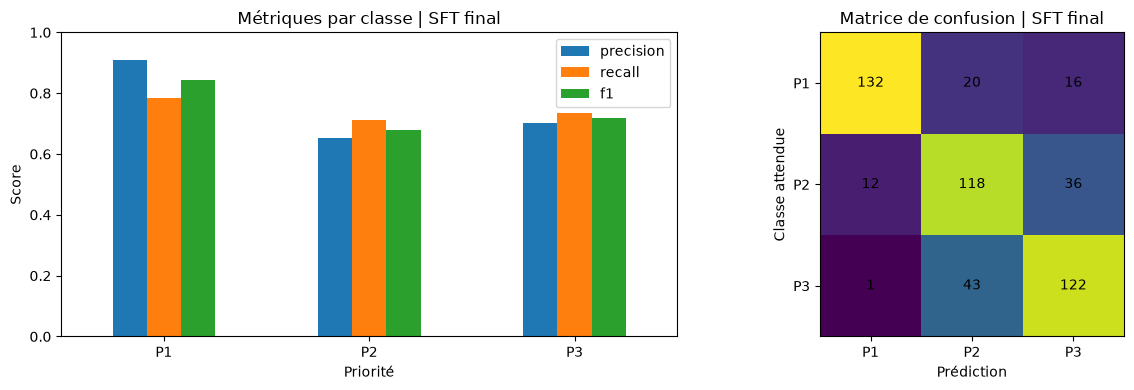

,stage,rows,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,undertriage_rate,accuracy_en,f1_macro_en,accuracy_fr,f1_macro_fr
0,SFT final,500,0.744,0.754476,0.743832,0.747071,0.747456,0.144,0.688,0.690276,0.8,0.802773


,stage,transition,count,support,rate_pct
0,SFT final,P1 → P2,20,168,11.904762
1,SFT final,P1 → P3,16,168,9.523810
2,SFT final,P2 → P3,36,166,21.686747


✓ Benchmark SFT final sauvegardé | checkpoint=checkpoint-950 | test=500


In [35]:
# Évalue le SFT sélectionné une seule fois sur le test figé puis sauvegarde le benchmark.
# Le checkpoint doit avoir été choisi uniquement à partir de la validation.

SFT_STAGE = (
    "SFT final"
    if SFT_CHECKPOINT == "best"
    else f"SFT checkpoint-{selected_checkpoint}"
)

print(f"Checkpoint évalué : {SFT_SELECTED_PATH}")
print(f"Stage              : {SFT_STAGE}")


# Prédictions sur le TEST figé.

sft_results_df = score_priorities(
    model,
    tokenizer,
    test_df
)                                                                       # Prédictions test


# Calcule les métriques de classification.

sft_metrics, sft_class_metrics, sft_confusion = evaluate_predictions(
    sft_results_df,
    stage=SFT_STAGE
)                                                                       # Métriques


# Analyse spécifiquement les erreurs de sous-triage.

sft_undertriage, sft_undertriage_details = undertriage_report(
    sft_results_df,
    stage=SFT_STAGE
)                                                                       # Sous-triage


# Affiche les métriques par classe et la matrice de confusion.

sft_figure = display_evaluation(
    sft_class_metrics,
    sft_confusion,
    SFT_STAGE
)                                                                       # Matrice confusion

display(pd.DataFrame([sft_metrics]))
display(sft_undertriage)


# Ajoute la provenance exacte du modèle au benchmark.

sft_metrics["checkpoint"] = str(SFT_SELECTED_PATH)
sft_metrics["checkpoint_step"] = int(selected_checkpoint)
sft_metrics["selection"] = str(SFT_CHECKPOINT)

if SFT_CHECKPOINT == "best":
    sft_metrics["selection_metric"] = "eval_f1_macro"
    sft_metrics["selection_validation_f1"] = float(SFT_BEST_F1)


# Sauvegarde pour comparaison SFT ↔ DPO sur exactement le même test.

sft_figure.savefig(
    RUN_METRIC_DIR / "sft_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight"
)

save_predictions(
    RUN_METRIC_DIR / "sft_predictions.jsonl",
    sft_results_df
)

save_predictions(
    RUN_METRIC_DIR / "sft_undertriage_details.jsonl",
    sft_undertriage_details
)

save_metrics(
    RUN_METRIC_DIR / "sft_metrics.json",
    sft_metrics
)

plt.close(sft_figure)

print(
    f"✓ Benchmark SFT final sauvegardé | "
    f"checkpoint={SFT_SELECTED_PATH.name} | "
    f"test={len(sft_results_df):,}"
)

In [36]:
# Journalise le benchmark SFT final dans un run W&B séparé.
# Conserve la provenance exacte de l'adapter évalué.

sft_test_run = start_wandb_run("sft-test", {
    "test_rows": len(sft_results_df),
    "inference_method": "conditional_priority_scoring",

    # Sélection du modèle
    "checkpoint_selection": str(SFT_CHECKPOINT),
    "checkpoint_step": int(selected_checkpoint),
    "checkpoint_path": str(SFT_SELECTED_PATH),
    "selection_metric": "eval_f1_macro",
    "selection_validation_f1": float(SFT_BEST_F1),

    # Provenance des données
    "train_sha256": file_sha256(SFT_TRAIN_PATH),
    "validation_sha256": file_sha256(SFT_VALIDATION_PATH),
    "test_sha256": file_sha256(SFT_TEST_PATH),

    # Reproductibilité
    "seed": CONFIG.seed
})

if sft_test_run:
    try:
        numeric_metrics = {
            f"test/{key}": value.item() if hasattr(value, "item") else value
            for key, value in sft_metrics.items()
            if isinstance(value, (int, float, np.integer, np.floating))
        }

        sft_test_run.log({
            **numeric_metrics,
            "test/predictions": wandb.Table(
                dataframe=sft_results_df
            ),
            "test/undertriage": wandb.Table(
                dataframe=sft_undertriage
            ),
            "test/confusion_matrix": wandb.Image(
                str(RUN_METRIC_DIR / "sft_confusion_matrix.png")
            )
        })

    finally:
        sft_test_run.finish()

print(
    f"✓ Benchmark SFT journalisé dans W&B | "
    f"checkpoint={SFT_SELECTED_PATH.name}"
)

test/accuracy,▁
test/accuracy_en,▁
test/accuracy_fr,▁
test/checkpoint_step,▁
test/f1_macro,▁
test/f1_macro_en,▁
test/f1_macro_fr,▁
test/f1_weighted,▁
test/precision_macro,▁
test/recall_macro,▁
+3,...


✓ Benchmark SFT journalisé dans W&B | checkpoint=checkpoint-950


In [37]:
def generate_sft_test(model, tokenizer, row, max_new_tokens=256):
    """Génère priorité + explication et contrôle la terminaison."""
    messages = [
        {"role": "system", "content": system_prompt(row["language"])},
        {"role": "user", "content": clinical_input(row)}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False
    ).to(model.device)

    im_end_id = tokenizer.convert_tokens_to_ids("<|im_end|>")

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=im_end_id,
            pad_token_id=tokenizer.pad_token_id
        )

    generated_ids = output[
        0,
        inputs["input_ids"].shape[1]:
    ].tolist()

    ended = im_end_id in generated_ids

    return {
        "text": tokenizer.decode(
            generated_ids,
            skip_special_tokens=True
        ).strip(),
        "ended": ended,
        "tokens": len(generated_ids),
        "im_end_position": (
            generated_ids.index(im_end_id)
            if ended
            else None
        )
    }

In [38]:
# Test qualitatif équilibré sur 9 cas du test figé.
# Échantillonne 3 cas par priorité avec une sélection reproductible.

sample = pd.concat([
    test_df.loc[test_df["priority"].eq(priority)]
    .sample(3, random_state=CONFIG.seed + priority)
    for priority in (1, 2, 3)
]).reset_index(drop=True)

generation_results = []

for _, row in sample.iterrows():
    result = generate_sft_test(
        model,
        tokenizer,
        row,
        max_new_tokens=512
    )

    generation_results.append({
        "id": row["id"],
        "expected": int(row["priority"]),
        "language": row["language"],
        "model_context": row["model_context"],
        **result
    })

    print("=" * 90)
    print(f"ID       : {row['id']}")
    print(f"ATTENDU  : P{row['priority']}")
    print(f"LANGUE   : {row['language']}")
    print(
        f"FIN      : "
        f"{'✓ <|im_end|>' if result['ended'] else '✗ ABSENT'}"
    )
    print(f"TOKENS   : {result['tokens']}")
    print()
    print(result["text"])

generation_df = pd.DataFrame(generation_results)

print(
    f"\n✓ Générations : {len(generation_df)} | "
    f"checkpoint={SFT_SELECTED_PATH.name}"
)

Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : 56988ee1630ead95b6281fdc
ATTENDU  : P1
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 40

PRIORITY: P1
EXPLANATION: Priority P1: (are) Drug Reactions. The case also documents the drug, the drugs. These documented clinical findings support immediate care.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : bb9ce92508d636f07f600c3f
ATTENDU  : P1
LANGUE   : fr
FIN      : ✓ <|im_end|>
TOKENS   : 54

PRIORITY: P1
EXPLANATION: Priorité P1 : retractions. Le dossier rapporte aussi 80.0, 100.0. Ces éléments cliniques documentés justifient une prise en charge immédiate.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

ID       : 9d82dc3958346a13a68c1cf8
ATTENDU  : P2
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 90

PRIORITY: P2
EXPLANATION: Priority P2: the presentation includes The patient has Neuroacanthocytosis. The patient presents with cardiac problems and movement disorders and acanthocytosis (abnormal, spiculated red blood cells), together with movement disorders and acanthocytosis (abnormal, spiculated red blood cells), Neuroacanthocytosis. These patient-specific findings support prompt assessment.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : 50c7812a1087d137360b307e
ATTENDU  : P3
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 75

PRIORITY: P3
EXPLANATION: Priority P3: Symptoms of PKD include - Pain in the back and lower sides - Headaches - Urinary tract infections - Blood in the urine Doctors diagnose PKD with imaging tests and family history. The case also documents (are) Kidney Cysts, kidney failure. These documented clinical findings support deferred care.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : b04e786dd80d07dfcd4fd01c
ATTENDU  : P3
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 96

PRIORITY: P2
EXPLANATION: Priority P2: in this patient, an increased risk of age-related macular degeneration. Other triage-relevant findings are age-related macular degeneration risk, or whether increased risk results from variations in both genes, age-related macular degeneration include genes involved in transporting and processing high-density lipoprotein (HDL, also known as "good" cholesterol) and gene. The documented presentation supports prompt assessment.
ID       : 1f8dff51475ea47856bb3b68
ATTENDU  : P3
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 72

PRIORITY: P2
EXPLANATION: Priority P2: in this patient, bronchopulmonary dysplasia (BPD). Other triage-relevant findings are BPD, doctors may recommend tests, such as, takes pictures of the structures inside the chest, such as the heart and lungs. The documented presentation supports prompt assessment.

✓ Générations : 9 | c

In [39]:
# Compare cible SFT et génération réelle sur les cas qualitatifs sélectionnés.

generation_audit_df = generation_df.merge(
    test_df[["id", "explanation"]],
    on="id",
    how="left"
)

for _, row in generation_audit_df.iterrows():
    print("=" * 100)
    print(f"ID       : {row['id']}")
    print(f"ATTENDU  : P{row['expected']}")
    print(f"LANGUE   : {row['language']}")
    print()

    print("CONTEXTE")
    print("-" * 100)
    print(row["model_context"])
    print()

    print("EXPLICATION ATTENDUE")
    print("-" * 100)
    print(row["explanation"])
    print()

    print("GÉNÉRATION")
    print("-" * 100)
    print(row["text"])
    print()

ID       : 56988ee1630ead95b6281fdc
ATTENDU  : P1
LANGUE   : en

CONTEXTE
----------------------------------------------------------------------------------------------------
Contexte médical:
The patient has (are) Drug Reactions. Clinical manifestations explicitly associated with the condition include But medicines can also cause unwanted reactions.

Informations patient:
condition_mentions: ["(are) Drug Reactions"]

Informations médicales:
medications: ["the drug"]
pathogens: ["the drugs"]
anatomy: ["skin", "stomach"]

EXPLICATION ATTENDUE
----------------------------------------------------------------------------------------------------
Priority P1: (are) Drug Reactions. The case also documents the drug, the drugs. These documented clinical findings support immediate care.

GÉNÉRATION
----------------------------------------------------------------------------------------------------
PRIORITY: P1
EXPLANATION: Priority P1: (are) Drug Reactions. The case also documents the drug, the 

In [40]:
# Résume la qualité structurelle des générations SFT.

generation_df["has_priority"] = (
    generation_df["text"]
    .str.match(r"^PRIORITY: P[123]")
)

generation_df["has_explanation"] = (
    generation_df["text"]
    .str.contains(r"\nEXPLANATION:\s*\S", regex=True)
)

display(
    generation_df[
        [
            "id",
            "expected",
            "language",
            "ended",
            "tokens",
            "has_priority",
            "has_explanation"
        ]
    ]
)

print(
    f"Terminaison <|im_end|> : "
    f"{generation_df['ended'].sum()}/{len(generation_df)} "
    f"({generation_df['ended'].mean() * 100:.1f} %)"
)

print(
    f"Format PRIORITY        : "
    f"{generation_df['has_priority'].mean() * 100:.1f} %"
)

print(
    f"Format EXPLANATION     : "
    f"{generation_df['has_explanation'].mean() * 100:.1f} %"
)

,id,expected,language,ended,tokens,has_priority,has_explanation
0,56988ee1630ead95b6281fdc,1,en,True,40,True,True
1,bb9ce92508d636f07f600c3f,1,fr,True,54,True,True
2,1cca922f4dab2d0005389ee3,1,fr,True,61,True,True
3,489404d1e35d85649304a4e0,2,en,True,54,True,True
4,fb3425033d3781d64259771a,2,en,True,60,True,True
5,9d82dc3958346a13a68c1cf8,2,en,True,90,True,True
6,50c7812a1087d137360b307e,3,en,True,75,True,True
7,b04e786dd80d07dfcd4fd01c,3,en,True,96,True,True
8,1f8dff51475ea47856bb3b68,3,en,True,72,True,True


Terminaison <|im_end|> : 9/9 (100.0 %)
Format PRIORITY        : 100.0 %
Format EXPLANATION     : 100.0 %


In [41]:
# Libération mémoire SFT.
# Supprime les objets lourds avant le DPO pour récupérer RAM et VRAM disponibles.

for name in ("sft_trainer", "model", "sft_train_output"):
    globals().pop(name, None)                                         # Retire les références restantes

gc.collect()                                                         # Libère les objets Python inaccessibles

if torch.cuda.is_available():
    torch.cuda.empty_cache()                                         # Libère le cache CUDA inutilisé
    torch.cuda.ipc_collect()                                         # Nettoie les allocations CUDA IPC

    free, total = torch.cuda.mem_get_info()

    print(
        f"✓ GPU libéré | "
        f"{free / 1024**3:.2f}/{total / 1024**3:.2f} Go disponibles"
    )

✓ GPU libéré | 3.56/6.00 Go disponibles


## 9. Conclusion et manifeste

Je termine en sauvegardant les versions, empreintes, chemins et métriques. Ce manifeste permet de relier un résultat aux données, aux adaptateurs et au groupe W&B qui l’ont produit.


In [42]:
# ## Manifest de reproductibilité SFT

# Centralise configuration, environnement, données, modèle et résultats.
# Les SHA-256 garantissent l'identité exacte des datasets évalués.

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),

    "run": {
        "stamp": RUN_STAMP,
        "group": RUN_GROUP,
        "wandb_project": WANDB_PROJECT if USE_WANDB else None,
    },

    "configuration": asdict(CONFIG),

    "environment": {
        "python": sys.version,
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "gpu": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        ),
    },

    "data": {
        "train": {
            "path": str(SFT_TRAIN_PATH),
            "sha256": file_sha256(SFT_TRAIN_PATH),
        },
        "validation": {
            "path": str(SFT_VALIDATION_PATH),
            "sha256": file_sha256(SFT_VALIDATION_PATH),
        },
        "test": {
            "path": str(SFT_TEST_PATH),
            "sha256": file_sha256(SFT_TEST_PATH),
            "rows": len(sft_results_df),
        },
    },

    "model": {
        "base": CONFIG.model_id,
        "selection": str(SFT_CHECKPOINT),
        "selected_checkpoint": str(SFT_SELECTED_PATH),
        "best_checkpoint": str(best_checkpoint),
        "adapter": str(SFT_SELECTED_PATH),
    },

    "results": {
        "global": sft_metrics,
        "per_class": sft_class_metrics.to_dict("records"),
    },
}


# Sauvegarde le manifest associé exactement au benchmark SFT réalisé.

MANIFEST_PATH = RUN_METRIC_DIR / "sft_experiment_manifest.json"

MANIFEST_PATH.write_text(
    json.dumps(
        manifest,
        ensure_ascii=False,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)


# Résume la provenance du modèle et du benchmark sauvegardé.

print("=== MANIFEST SFT ===")
print(f"Run         : {RUN_STAMP}")
print(f"Sélection   : {SFT_CHECKPOINT}")
print(f"Best        : {best_checkpoint}")
print(f"Évalué      : {SFT_SELECTED_PATH}")
print(f"Manifest    : {MANIFEST_PATH}")

=== MANIFEST SFT ===
Run         : 20261007-003909
Sélection   : best
Best        : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints\checkpoint-950
Évalué      : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\sft_checkpoints\checkpoint-950
Manifest    : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\metrics\20261007-003909\sft_experiment_manifest.json
